In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import Input, Rescaling, Dense, Conv2D, Dropout, MaxPooling2D, AveragePooling2D, Flatten, BatchNormalization
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

In [16]:
# UNIVERSAL CONFIG
HEIGHT = 28
WIDTH = 28
CHANNEL = 1
BATCH_SIZE = 64
SEED = 26
VALIDATION_RATIO = 0.1
TEST_RATIO = 0.2
ALLOW_SHUFFLE = True
EPOCHS = 20

In [3]:
def result_report(y_true, y_pred):
    return f"""
================================================
  Accuracy: {accuracy_score(y_true, y_pred):.4f}
  Precision: {precision_score(y_true, y_pred, average='macro'):.4f}
  Recall: {recall_score(y_true, y_pred, average='macro'):.4f}
================================================
    """

In [4]:
raw_mnist_train, raw_mnist_test = image_dataset_from_directory(
    "data/trainingSet/trainingSet",
    image_size=(WIDTH, HEIGHT),
    color_mode='grayscale',
    batch_size=None,
    label_mode='int',
    seed=SEED,
    validation_split=TEST_RATIO,
    shuffle=ALLOW_SHUFFLE,
    subset="both"
    )

#raw_mnist_train = raw_mnist_train.batch(BATCH_SIZE, drop_remainder=True)
#raw_mnist_test = raw_mnist_test.batch(BATCH_SIZE, drop_remainder=True)

Found 42000 files belonging to 10 classes.
Using 33600 files for training.
Using 8400 files for validation.


Tensor shape: (28, 28, 1)
Image resolution:  (28, 28)
Label of current image: 0


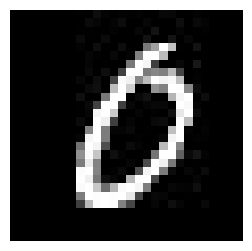

Tensor shape: (28, 28, 1)
Image resolution:  (28, 28)
Label of current image: 3


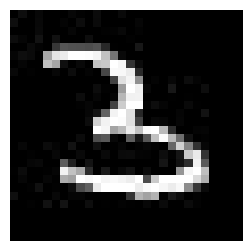

Tensor shape: (28, 28, 1)
Image resolution:  (28, 28)
Label of current image: 3


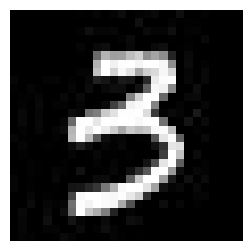

In [5]:
# PREVIEW
for mnist_matrix, mnist_label in raw_mnist_train.take(3):
    # Original type is matrix but using heatmap to visualize

    print("Tensor shape:", mnist_matrix.shape)
    mnist_matrix = mnist_matrix.numpy().squeeze(axis=-1) # transform (28, 28, 1) --> (28, 28)
    print("Image resolution: ", mnist_matrix.shape)
    print("Label of current image:", mnist_label.numpy())

    plt.figure(figsize=(3, 3))
    sns.heatmap(mnist_matrix, xticklabels=False, yticklabels=False, cbar=False, vmin=0, vmax=255, cmap='binary_r')
    plt.show()

In [ ]:
# Extract image matrices / labels individually
mnist_mtx_train = []
mnist_label_train = []
for mtx, label in raw_mnist_train:
    mnist_mtx_train.append(mtx.numpy().astype('float32'))
    mnist_label_train.append(label.numpy().astype('int32'))

mtx_train = np.stack(mnist_mtx_train, axis=0)
label_train = np.stack(mnist_label_train, axis=0).reshape(-1,1)

In [7]:
mnist_mtx_test = []
mnist_label_test = []
for mtx, label in raw_mnist_test:
    mnist_mtx_test.append(mtx.numpy().astype('float32'))
    mnist_label_test.append(label.numpy().astype('int32'))

mtx_test = np.stack(mnist_mtx_test, axis=0)
label_test = np.stack(mnist_label_test, axis=0).reshape(-1,1)

In [8]:
print(mtx_train.shape)
#print(mtx_train[0][0].squeeze(axis=-1))
print(label_train.shape)
print(label_test.shape)
print(label_test)
print(label_train)

(33600, 28, 28, 1)
(33600, 1)
(8400, 1)
[[1]
 [0]
 [6]
 ...
 [5]
 [2]
 [7]]
[[4]
 [7]
 [6]
 ...
 [1]
 [8]
 [1]]


In [9]:
autotune = tf.data.AUTOTUNE
X_train = mtx_train#.cache().prefetch(buffer_size=autotune)
y_train = label_train#.cache().prefetch(buffer_size=autotune)
X_test = mtx_test#.cache().prefetch(buffer_size=autotune)
y_test = label_test#.cache().prefetch(buffer_size=autotune)

In [22]:
# CNN DESIGN
tf.keras.backend.clear_session()

cnn_mdl = Sequential([
    # Input is one image matrix (value range [0, 255])
    Input(shape=(WIDTH,HEIGHT,CHANNEL)),
    # Scaling values to [0,1]
    Rescaling(1./255),

    # First Convolutional Block
    Conv2D(filters=32, activation='relu', kernel_size=(3,3), strides=(1,1), kernel_initializer='he_uniform', kernel_regularizer=regularizers.L2(0.01), bias_regularizer=regularizers.L2(0.01)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolutional Block
    Conv2D(filters=64, activation='relu', kernel_size=(3,3), strides=(1,1), kernel_initializer='he_uniform', kernel_regularizer=regularizers.L2(0.01), bias_regularizer=regularizers.L2(0.01)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu', kernel_initializer='he_uniform', kernel_regularizer=regularizers.L2(0.01), bias_regularizer=regularizers.L2(0.01)),
    Dropout(rate=0.4),

    # This return probabilities of categories
    Dense(10, activation='softmax')
])

cnn_mdl.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

cnn_mdl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

In [23]:
history = cnn_mdl.fit(
    x=X_train,
    y=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    validation_split=VALIDATION_RATIO,
    verbose=1
)
cnn_mdl.save("cnn_mnist_classifier.keras")

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.9204 - loss: 2.3043 - val_accuracy: 0.9563 - val_loss: 0.9265
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9649 - loss: 0.5792 - val_accuracy: 0.9738 - val_loss: 0.3812
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9702 - loss: 0.3526 - val_accuracy: 0.9783 - val_loss: 0.2935
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9723 - loss: 0.3033 - val_accuracy: 0.9747 - val_loss: 0.2820
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9743 - loss: 0.2681 - val_accuracy: 0.9685 - val_loss: 0.2866
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9755 - loss: 0.2568 - val_accuracy: 0.9652 - val_loss: 0.2965
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9768 - loss: 0.2414 - val_accuracy: 0.9818 - val_loss: 0.2385
Epoch 8/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9774 - loss: 0.2383 - 

In [24]:
mdl = tf.keras.models.load_model("cnn_mnist_classifier.keras")

In [25]:
cnn_y_pred = mdl.predict(X_test, batch_size=BATCH_SIZE)
cnn_y_pred = np.argmax(cnn_y_pred, axis=1).reshape(-1,1)
print(cnn_y_pred)
print(y_test)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
[[1]
 [0]
 [6]
 ...
 [5]
 [2]
 [7]]
[[1]
 [0]
 [6]
 ...
 [5]
 [2]
 [7]]


In [26]:
print(result_report(y_test, cnn_y_pred))


  Accuracy: 0.9851
  Precision: 0.9850
  Recall: 0.9851
    
